# 08 - Explainable AI (XAI) with Grad-CAM

In medical imaging, black-box predictions are not enough. Clinicians need to know **where** the model is looking.
This notebook implements **Grad-CAM (Gradient-weighted Class Activation Mapping)** to visualize the exact regions (Region of Interest / ROI) that triggered the model's decision (tumor detection).

In [22]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from dotenv import load_dotenv

# Add src directory to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.models import TransferCNN

%matplotlib inline

## 1. Load Trained Model & Sample Test Images

In [26]:
# Load test dataset tensors (from previous splits or augmented folder)
PROCESSED_DIR = os.getenv("PROCESSED_DIR", os.path.join("..", "data", "processed"))
AUG_DIR = os.path.join(PROCESSED_DIR, "augmented_images")
if not os.path.exists(AUG_DIR):
    AUG_DIR = os.path.join("data", "processed", "augmented_images")

# Load one positive sample (tumor) and one negative sample (no tumor)
yes_dir = os.path.join(AUG_DIR, "yes")
no_dir = os.path.join(AUG_DIR, "no")

sample_tumor_path = os.path.join(yes_dir, os.listdir(yes_dir)[0]) if os.path.exists(yes_dir) and os.listdir(yes_dir) else None
sample_healthy_path = os.path.join(no_dir, os.listdir(no_dir)[0]) if os.path.exists(no_dir) and os.listdir(no_dir) else None

print(f"Sample tumor tensor found: {sample_tumor_path is not None}")

Sample tumor tensor found: True


## 2. Grad-CAM Implementation for PyTorch CNNs
We define a robust Grad-CAM class that hooks into the last convolutional layer of the model.

In [27]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
        
    def __call__(self, x, class_idx=None):
        self.model.eval()
        output = self.model(x)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
            
        score = output[:, class_idx]
        
        self.model.zero_grad()
        score.backward()
        
        # Global average pooling of gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight the activations by pooled gradients
        activations = self.activations.squeeze(0)
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap, output

## 3. Generating and Visualizing Heatmaps

Loading of local weights of ResNet50 since : ../models\resnet50-retrained.pth


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


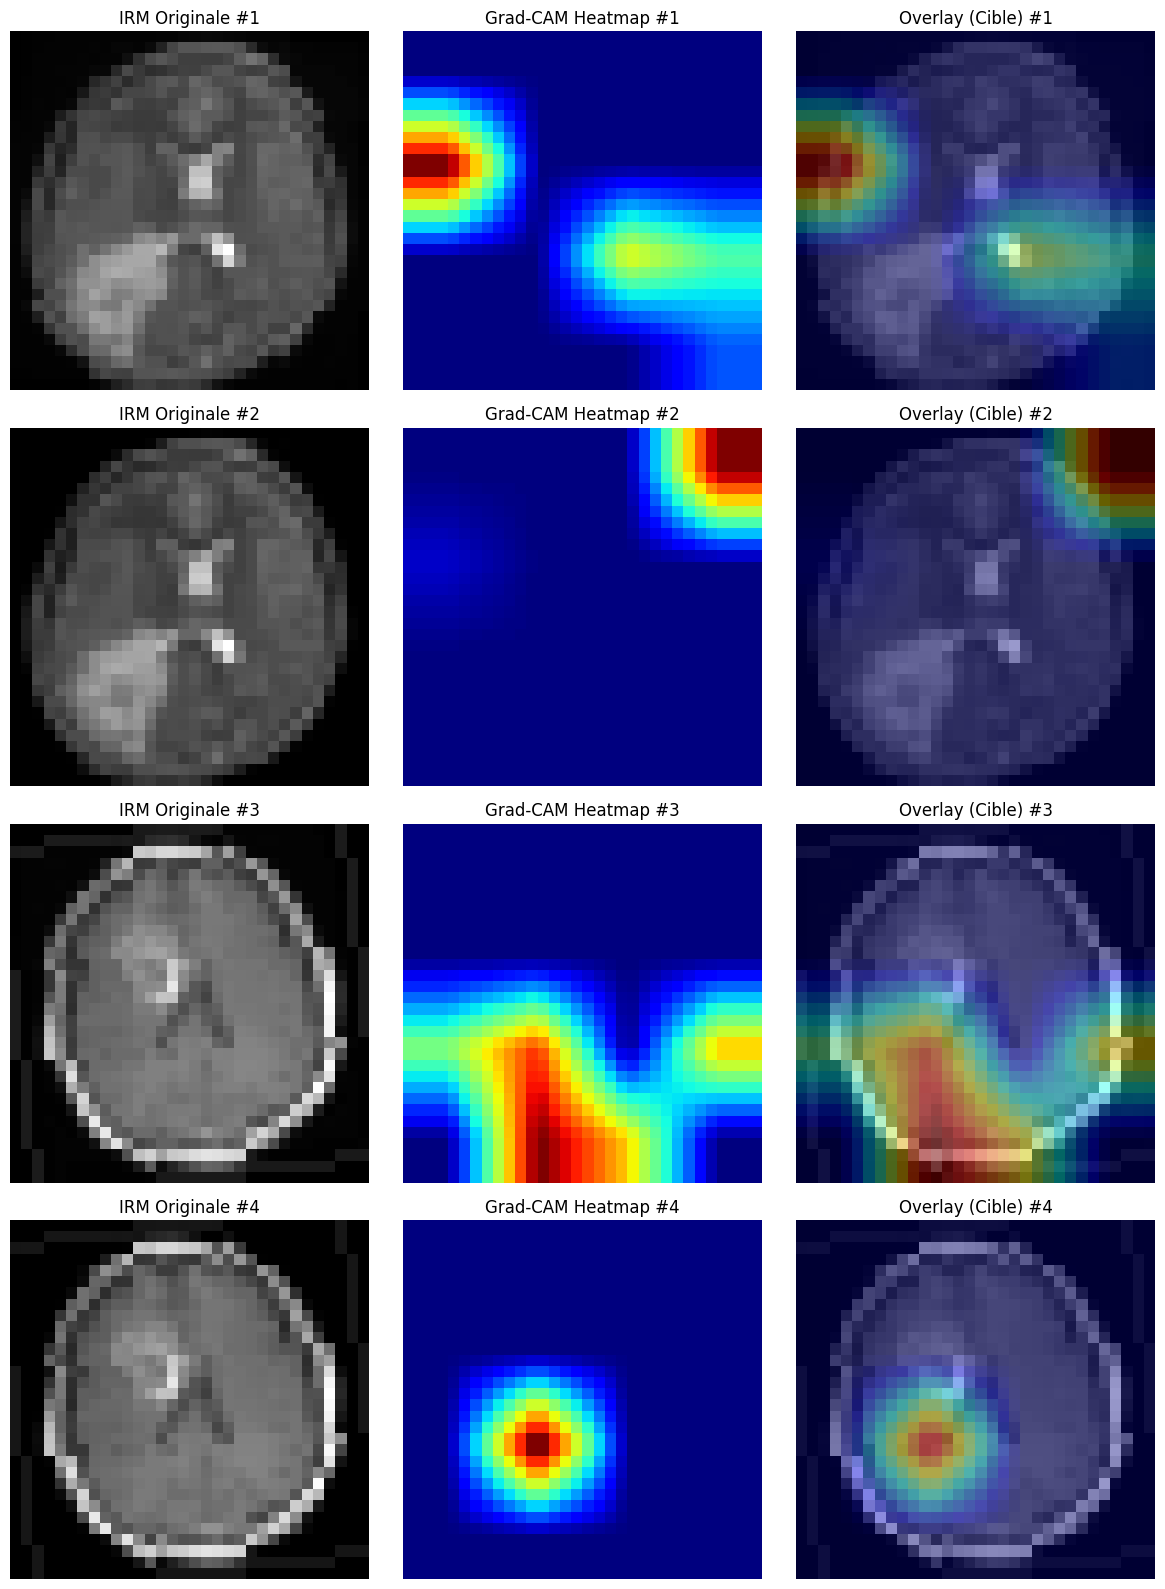

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Loading of the trained model (ResNet50) and its weights
model = TransferCNN(model_name='resnet50', num_classes=2)
model_weights_path = os.path.join("..", "models", "resnet50_retrained.pth")
if not os.path.exists(model_weights_path):
    model_weights_path = os.path.join("models", "resnet50_retrained.pth")

if os.path.exists(model_weights_path):
    model.load_state_dict(torch.load(model_weights_path, map_location='cpu'), strict=False)
    print("✅ Model and weights loaded successfully.")

# Target layer (layer2[-1] according to your successful tests)
target_layer = model.base_model.layer2[-1]
grad_cam = GradCAM(model, target_layer)

# 2. Retrieval of paths for positive images (tumors) and negative images (no tumors)
PROCESSED_DIR = os.getenv("PROCESSED_DIR", os.path.join("..", "data", "processed"))
AUG_DIR = os.path.join(PROCESSED_DIR, "augmented_images")
if not os.path.exists(AUG_DIR):
    AUG_DIR = os.path.join("data", "processed", "augmented_images")

yes_dir = os.path.join(AUG_DIR, "yes")

if os.path.exists(yes_dir):
    # Selection of a few positive samples (tumors) for Grad-CAM visualization
    tumor_files = [f for f in os.listdir(yes_dir) if f.endswith('.pt')][:4]
    num_samples = len(tumor_files)
    
    if num_samples > 0:
        # Creation of subplots for visualization
        fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
        if num_samples == 1:
            axes = np.array([axes]) 
            
        for idx, file_name in enumerate(tumor_files):
            tensor_path = os.path.join(yes_dir, file_name)
            tensor_img = torch.load(tensor_path).unsqueeze(0) # [1, C, H, W]
            
            # Grad-CAM computation
            heatmap, output = grad_cam(tensor_img, class_idx=1)
            
            # Preparation of the original image for visualization
            img_np = tensor_img.squeeze(0).permute(1, 2, 0).numpy()
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
            
            # Redimensionnement et coloration de la heatmap
            heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
            heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
            heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
            
            # Superposition (Overlay)
            overlay = 0.6 * img_np + 0.4 * heatmap_colored
            
            # Visualization of the original image, heatmap, and overlay
            axes[idx, 0].imshow(img_np)
            axes[idx, 0].set_title(f"IRM Originale #{idx+1}")
            axes[idx, 0].axis('off')
            
            axes[idx, 1].imshow(heatmap_resized, cmap='jet')
            axes[idx, 1].set_title(f"Grad-CAM Heatmap #{idx+1}")
            axes[idx, 1].axis('off')
            
            axes[idx, 2].imshow(overlay)
            axes[idx, 2].set_title(f"Overlay (Cible) #{idx+1}")
            axes[idx, 2].axis('off')
            
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No files .pt found in the 'yes' directory.")
else:
    print(f"⚠️ Directory '{yes_dir}' not found.")

### Critical Analysis, Limitations, and Improvement Prospects (Grad-CAM)

Although the model achieves excellent classification performance, the analysis of Grad-CAM heatmaps reveals nuanced behaviors and highlights crucial areas for improvement in future research:

* **Concordance and Variability:** On many samples, the peak activation zone (red/yellow) overlays precisely onto the tumor lesion, confirming that the network relies on the correct **Region of Interest (ROI)**. However, on other cases, the map appears more diffuse or slightly misaligned.
* **Shortcut Learning Phenomenon:** A model can correctly predict the presence of a tumor while occasionally relying on global contextual signals (such as overall brain structure asymmetry or background contrasts) rather than the strict contours of the lesion.
* **Spatial Resolution Trade-off:** The choice of the target layer (e.g., between intermediate and deep layers) involves a trade-off: intermediate layers preserve finer spatial details but are noisier, whereas final layers offer strong semantic coherence at the expense of millimeter-level precision.
* **Impact of Dataset Size and Diversity:** **Expanding the training dataset** is a fundamental lever for making explainability more reliable. By increasing the volume of images with greater inter-patient and inter-scanner variability, the network learns to overcome artifacts and spurious correlations. This would yield Grad-CAM activations that are much more stable, sharp, and strictly circumscribed to pathological anatomical zones.
* **Methodological Rigor:** Highlighting these imperfections demonstrates an objective scientific approach (absence of *cherry-picking*), illustrating the inherent complexity of interpreting neural black boxes in medical imaging.